In [1]:
from mlx.nn import ReLU
import mlx.data as dx
import mlx.core as mx

from importlib import reload

import src.processing
reload(src.processing)

from src.config import OptimizerConfig, EncoderConfig
from src.processing import get_all_dataset, get_trades_tokenizer, get_volatility_seq, save_tokenizer, load_tokenizer, get_num_embedding_tokenizer, compute_df_feature, encode_df_feature, load_market_cap
from copy import deepcopy

from dotenv import load_dotenv
import os 
import polars as pl

load_dotenv()
info_url = os.getenv("markr_url")
print("INFO URL->", info_url)

market_cap = load_market_cap(info_url)
FILTER = (pl.col("marketCap") < 1_000_000_000) & (pl.col("isActive"))
selected_isins = market_cap.filter(FILTER).select("isin")
print(f"Total isins select {len(selected_isins)}/{len(market_cap)}")

CATEGORIAL_COLUMNS = ["TradeType", "MifidInstrumentID", "MmtMarketMechanism", "MmtTradingMode", "MmtAlgorithmicIndicator", "Venue"]
CONTINUOUS_COLUMNS = ["delta_event_ts", "time_cos", "time_sin", "norm_volume"]
SEQUENCE_SIZE = 20
VOLATILITY_SCALE = 1.
SAVE_DIR = "weight"
ENCODER_DEPTH = 4
EMBEDDING_DIM = [4, 8, 4, 4, 4, 4] # 8 for InstrumentID to get better clustering

dataset = get_all_dataset(dir="equities_trade")
dataset = dataset.filter(pl.col("MifidInstrumentID").is_in(selected_isins["isin"].implode()))

print(f"👾 Load {len(dataset)} trades")
print(dataset.tail(1))

tokenizer = load_tokenizer(path="tokenizer.json") 

raw_data = deepcopy(dataset) # we need it for next ceil
dataset = encode_df_feature(dataset, tokenizer)
dataset = compute_df_feature(dataset, norm_log_return_window=10, norm_volume_window=10)


encoder_config = EncoderConfig(num_continuous_col=len(CONTINUOUS_COLUMNS), 
                              depth=ENCODER_DEPTH,
                              embedding_dim=EMBEDDING_DIM,
                              num_embedding=get_num_embedding_tokenizer(tokenizer, CATEGORIAL_COLUMNS),
                              categorical_col=CATEGORIAL_COLUMNS)

print("[TEST] ", get_num_embedding_tokenizer(tokenizer, CATEGORIAL_COLUMNS))
dataset


INFO URL-> https://api.markr.black/v1/stocks/
Total isins select 624/1039
Found 6 files in directory
👾 Load 742890 trades
shape: (1, 12)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────┐
│ EventTime  ┆ TradingDat ┆ Publicatio ┆ MifidInst ┆ … ┆ MmtMarket ┆ MmtTradin ┆ MmtAlgori ┆ Venue │
│ ---        ┆ eTime      ┆ nDateTime  ┆ rumentID  ┆   ┆ Mechanism ┆ gMode     ┆ thmicIndi ┆ ---   │
│ str        ┆ ---        ┆ ---        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ cator     ┆ str   │
│            ┆ str        ┆ str        ┆ str       ┆   ┆ str       ┆ str       ┆ ---       ┆       │
│            ┆            ┆            ┆           ┆   ┆           ┆           ┆ str       ┆       │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════╡
│ 2026-03-12 ┆ 2026-03-12 ┆ 2026-03-12 ┆ FR001400A ┆ … ┆ 4         ┆ 5         ┆ human     ┆ XPAR  │
│ T16:55:52. ┆ T16:55:23. ┆ T16:55:53. ┆ HX6       ┆   

MifidInstrumentID,delta_ts,log_return,log_volume,norm_log_return,norm_volume,TradeType,MmtMarketMechanism,MmtTradingMode,MmtAlgorithmicIndicator,Venue,event_ts,time_cos,time_sin,MifidPrice
i32,list[f64],list[f64],list[f64],list[f64],list[f64],list[i32],list[i32],list[i32],list[i32],list[i32],list[i64],list[f64],list[f64],list[f64]
551,"[0.0, 0.0, … 2.8523e-10]","[0.0, 0.0, … 0.0]","[6.023448, 5.049856, … 9.094368]","[0.0, 0.0, … 0.0]","[0.371351, -0.714044, … 1.841532]","[4, 4, … 4]","[0, 0, … 0]","[4, 4, … 0]","[0, 1, … 1]","[1, 1, … 1]","[1773043210968163, 1773043210968163, … 1774024509368166]","[1.0, 1.0, … 0.908603]","[0.0, 0.0, … 0.417662]","[0.166, 0.166, … 0.168]"
274,[],[],[],[],[],[],[],[],[],[],[],[],[],[]
283,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[2.397895, 1.791759, … 4.890349]","[0.0, 0.0, … 0.0]","[-0.552148, -0.944278, … 1.063061]","[4, 4, … 4]","[0, 0, … 0]","[4, 4, … 0]","[0, 0, … 0]","[2, 2, … 2]","[1773043215043306, 1773043215043306, … 1774024520252825]","[1.0, 1.0, … 0.908018]","[0.0, 0.0, … 0.418932]","[5.55, 5.55, … 5.68]"
542,"[1.5971e-7, 1.7874e-7, … 5.4113e-7]","[-0.004662, 0.0, … 0.008889]","[4.430817, 6.342121, … 6.198479]","[-0.004196, 0.000466, … 0.008]","[-1.971857, -0.174915, … -2.321992]","[4, 4, … 4]","[0, 0, … 0]","[1, 1, … 0]","[0, 0, … 0]","[2, 2, … 2]","[1773043830539593, 1773044147459362, … 1774024501470249]","[0.991654, 0.981171, … 0.908415]","[0.128928, 0.193141, … 0.418069]","[0.107, 0.107, … 0.113]"
18,"[0.0, 7.5420e-7, … 0.0]","[0.0, 0.0, … 0.0]","[11.049317, 13.919646, … 13.841203]","[-0.010536, -0.010536, … 0.0]","[-0.19627, 2.272448, … 3.842973]","[4, 4, … 4]","[0, 0, … 0]","[1, 1, … 0]","[0, 1, … 1]","[2, 2, … 2]","[1773044375664874, 1773045712898508, … 1774024501490579]","[0.971424, 0.870679, … 0.909074]","[0.237351, 0.491852, … 0.416635]","[0.001, 0.001, … 0.001]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
110,"[0.000048, 0.000003, … 0.000034]","[-0.007491, 0.007491, … -0.007067]","[0.693147, 3.044522, … 0.693147]","[-0.007491, 0.005987, … -0.00636]","[-1.519254, 0.596983, … -1.52762]","[4, 4, … 4]","[0, 0, … 0]","[4, 1, … 4]","[1, 1, … 1]","[2, 2, … 2]","[1773388827366530, 1773395014962906, … 1773993627489045]","[-0.277759, -0.999823, … 0.930915]","[0.960651, 0.018817, … 0.365236]","[1.33, 1.34, … 1.41]"
226,"[0.0, 0.0, … 5.7987e-7]","[-0.003945, -0.00396, … 0.0]","[3.526361, 3.332205, … 3.7612]","[-0.00355, -0.00317, … -0.000781]","[0.292484, -0.165578, … 0.573964]","[4, 7, … 4]","[0, 0, … 0]","[1, 1, … 0]","[1, 0, … 0]","[2, 2, … 2]","[1773049015404865, 1773049015404865, … 1774024529500454]","[0.367869, 0.367869, … 0.905923]","[0.929878, 0.929878, … 0.423443]","[12.65, 12.6, … 12.85]"
256,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[3.912023, 2.564949, … 0.693147]","[0.0, 0.0, … -0.004124]","[1.298751, -0.021496, … -1.743167]","[4, 4, … 4]","[0, 0, … 0]","[4, 4, … 0]","[0, 0, … 1]","[2, 2, … 2]","[1773043224895171, 1773043224895171, … 1774024521551728]","[1.0, 1.0, … 0.908752]","[0.0, 0.0, … 0.417337]","[31.9, 31.9, … 29.7]"


[8 4 4 4 4 4]


100%|██████████| 425/425 [00:04<00:00, 93.25it/s] 


[RUN] Start processing latent...


5it [00:00, 28.64it/s]


[RUN] z shape (5000, 16) lr shape:  (5000,)
Quantiles:  [0.00960007 0.01707198]


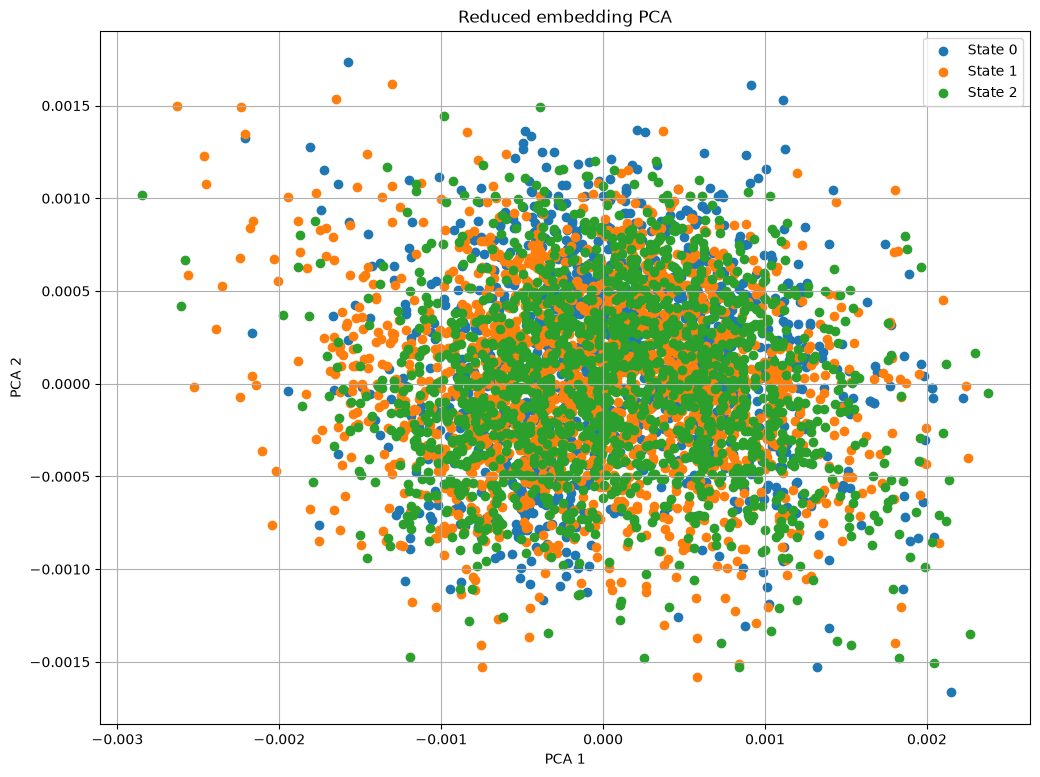

/Users/arseneducrocq/Documents/intern-project/clustering-euronext-trades/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Total state-> [0 1 2]


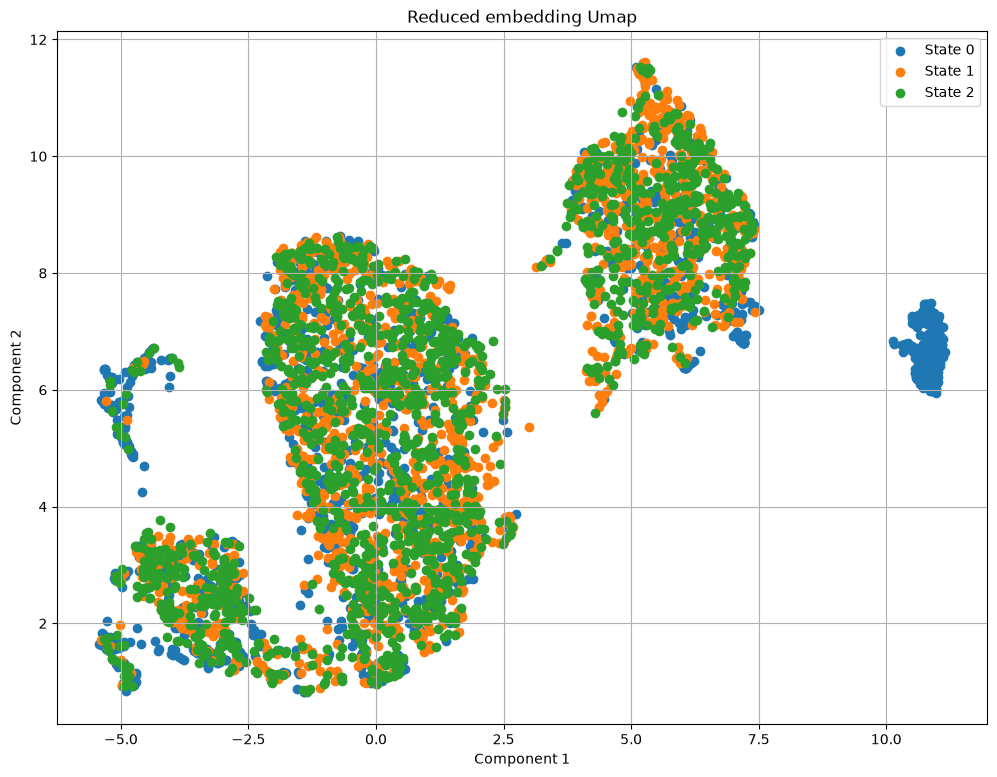

In [10]:
import src.clustering
import src.processing
import importlib
importlib.reload(src.clustering)
importlib.reload(src.processing)
from src.clustering import run_analyse, run_latent_analyse
from src.processing import get_dataset_volatility, get_num_embedding, get_vae_seq, get_vae_seq_with_lr, get_vae_seq_with_var
from src.config import VAEConfig, EncoderConfig
from src.vae import VAE
import polars as pl
import numpy as np
import mlx.core as mx
import time

CATEGORICAL_COLUMNS_NO_AGNO = ["MifidInstrumentID", "TradeType", "MmtMarketMechanism", "MmtTradingMode", "MmtAlgorithmicIndicator", "Venue"] 
CONTINUOUS_COLUMNS_NO_AGNO = ["log_return", "delta_ts", "time_cos", "time_sin", "norm_volume"] # "Volatility20", "Volatility40", "Volatility80", 
EMBEDDING_DIM_NO_AGNO= np.full(len(CATEGORICAL_COLUMNS_NO_AGNO), fill_value=4)
EMBEDDING_DIM_NO_AGNO[0]=8
print(EMBEDDING_DIM_NO_AGNO)

SAMPLE_SIZE = 5000

encoder_no_agno_config = EncoderConfig(num_continuous_col=len(CONTINUOUS_COLUMNS_NO_AGNO), 
                              depth=ENCODER_DEPTH,
                              embedding_dim=EMBEDDING_DIM_NO_AGNO,
                              num_embedding=get_num_embedding(dataset, CATEGORICAL_COLUMNS_NO_AGNO),
                              categorical_col=CATEGORICAL_COLUMNS_NO_AGNO)

vae_no_agno_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

vae_model = VAE(encoder_config=encoder_no_agno_config, vae_config=vae_no_agno_config).load_weights("weight/vae_no_agno_32.safetensors")
mx.eval(vae_model.parameters()) 

vae_sequence = get_vae_seq_with_var(data=dataset, categorical_col=CATEGORICAL_COLUMNS_NO_AGNO, continous_col=CONTINUOUS_COLUMNS_NO_AGNO, sq_size=SEQUENCE_SIZE)
start = time.time()
vae_stream = dx.buffer_from_vector(vae_sequence[: SAMPLE_SIZE]).to_stream().batch(1024)

#result = run_analyse(df=dataset, col="MifidInstrumentID", model=vae_model, tokenizer=tokenizer)
result = run_latent_analyse(vae_model, vae_stream, CATEGORICAL_COLUMNS_NO_AGNO, col="var")

Best score 0.6035673022270203 for n= 10


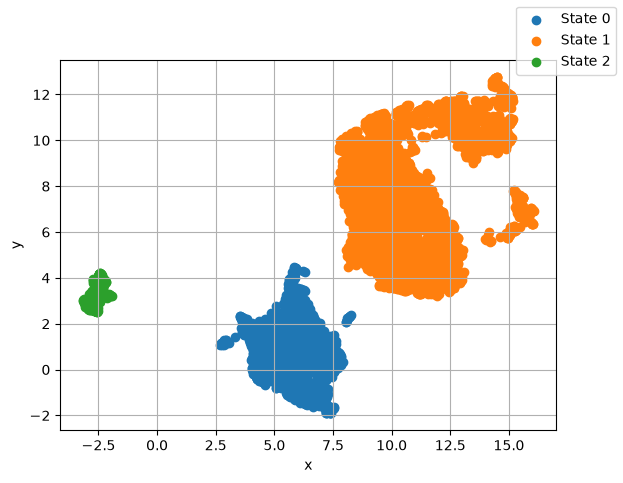

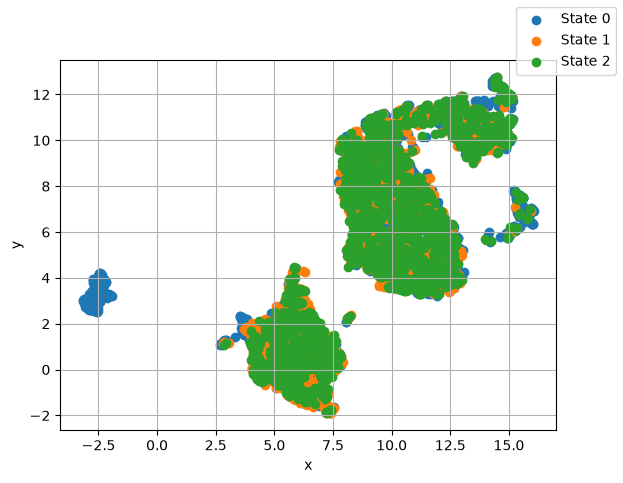

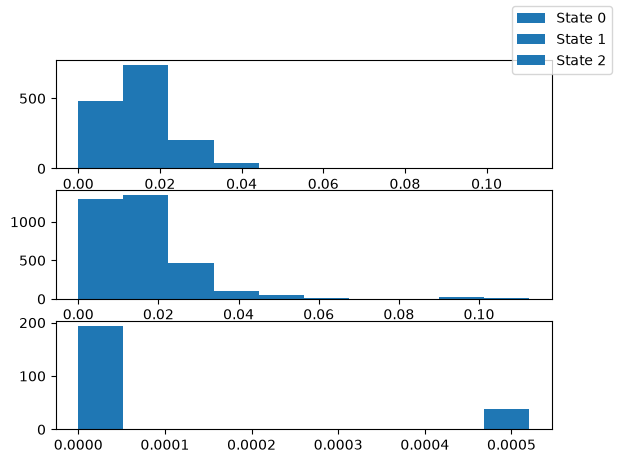

In [ ]:
import umap
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def scatter_plot_with_label(x, y, labels, x_lab="x", y_lab="y"):
    labels_unique = np.unique(labels)
    fig, ax = plt.subplots()
    for label in labels_unique:
        ax.scatter(x[labels == label], y[labels == label], label=f"State {label}")
    ax.set_xlabel(x_lab)
    ax.set_ylabel(y_lab)
    ax.grid()
    fig.legend()
    return fig

def plot_hist_with_label(x, labels):
    labels_unique = np.unique(labels)
    fig, ax = plt.subplots(nrows=len(labels_unique))
    
    for i, label in enumerate(labels_unique):
        ax[i].set_title(f"State {label}")
        ax[i].hist(x[labels == label])
    return fig 

seed=21
z = result["z"]
n_neighbors = np.arange(5, 25, 5)

best_n=-1
best_score =-1

for n in n_neighbors:
    um = umap.UMAP(n_neighbors=n) 
    z_um = um.fit_transform(z)
    model = KMeans(n_clusters=3)
    y_pred = model.fit_predict(z_um)
    score = silhouette_score(z_um, y_pred)
    if score > best_score:
        best_score=score
        best_n = n
        best_z = z_um
        best_pred = y_pred

print("Best score", best_score, "for n=", best_n)

fig = scatter_plot_with_label(best_z[:, 0], best_z[:, 1], best_pred)
plt.show()

fig2 = scatter_plot_with_label(best_z[:, 0], best_z[:, 1], result["categories"])
plt.show()

fig3 = plot_hist_with_label(result["raw_categories"], best_pred)
plt.show()